Task 1 -- GPT-style LLM from scratch (character-level), TinyStories.
Author: Charvee

Architecture (own design, deliberately different from teammate's, no prebuilt
Transformer/attention modules):
  - Post-LayerNorm Transformer blocks: x = LN(x + Attn(x)); x = LN(x + FFN(x))
  - Manually implemented scaled dot-product multi-head self-attention with a causal mask
  - ReLU feed-forward network (not GELU)
  - Learned token + positional embeddings, NO weight tying (separate LM head)
  - Config: n_layer=6, n_head=4, n_embd=96, block_size=96, dropout=0.15 (deeper & narrower
    than teammate's 4-layer/128-dim model)
  - AdamW with linear warmup -> linear decay (not cosine)
  - Independent data slice: takes the SECOND 110K-character window of the shared corpus

In [1]:
import json
import math
import os
import time

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

### Config

In [2]:
SEED = 7
BLOCK_SIZE = 96
N_LAYER = 6
N_HEAD = 4
N_EMBD = 96
DROPOUT = 0.15
BATCH_SIZE = 48
N_EPOCHS = 60
PEAK_LR = 5e-4
WARMUP_FRAC = 0.1
TRAIN_CHARS = 100_000
VAL_CHARS = 10_000
DATA_OFFSET = 150_000  # Charvee's independent slice (non-overlapping with Ishan's 0:110_000)

try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:  # running inside a Jupyter notebook (nbconvert cwd = notebook's dir)
    HERE = os.path.abspath(".")
MEMBER_DIR = os.path.dirname(HERE)
DATA_PATH = os.path.join(MEMBER_DIR, "..", "data", "tinystories_raw.txt")
CKPT_DIR = os.path.join(MEMBER_DIR, "checkpoints")
OUT_DIR = os.path.join(MEMBER_DIR, "outputs")
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


### 1.1 Data preprocessing -- char-level tokenizer + own train/val split

In [3]:
with open(DATA_PATH, "r", encoding="utf-8") as f:
    full_text = f.read()

slice_text = full_text[DATA_OFFSET: DATA_OFFSET + TRAIN_CHARS + VAL_CHARS]
train_text = slice_text[:TRAIN_CHARS]
val_text = slice_text[TRAIN_CHARS: TRAIN_CHARS + VAL_CHARS]
assert len(train_text) == TRAIN_CHARS and len(val_text) == VAL_CHARS

chars = sorted(list(set(full_text)))
vocab_size = len(chars)
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

def encode(s):
    return [char_to_idx[c] for c in s]

def decode(ids):
    return "".join(idx_to_char[i] for i in ids)

train_ids = torch.tensor(encode(train_text), dtype=torch.long)
val_ids = torch.tensor(encode(val_text), dtype=torch.long)
print(f"Vocab size: {vocab_size} | train chars: {len(train_ids)} | val chars: {len(val_ids)}")

with open(os.path.join(OUT_DIR, "vocab.json"), "w") as f:
    json.dump({"char_to_idx": char_to_idx, "idx_to_char": idx_to_char}, f)


def get_batch(split):
    data = train_ids if split == "train" else val_ids
    ix = torch.randint(0, len(data) - BLOCK_SIZE - 1, (BATCH_SIZE,))
    x = torch.stack([data[i:i + BLOCK_SIZE] for i in ix])
    y = torch.stack([data[i + 1:i + BLOCK_SIZE + 1] for i in ix])
    return x.to(device), y.to(device)


STEPS_PER_EPOCH = max(1, (TRAIN_CHARS // BLOCK_SIZE) // BATCH_SIZE)
TOTAL_STEPS = STEPS_PER_EPOCH * N_EPOCHS
WARMUP_STEPS = max(1, int(TOTAL_STEPS * WARMUP_FRAC))

Vocab size: 93 | train chars: 100000 | val chars: 10000


### 1.2 GPT model implementation from scratch

In [4]:
class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        self.key = nn.Linear(n_embd, n_embd)
        self.query = nn.Linear(n_embd, n_embd)
        self.value = nn.Linear(n_embd, n_embd)
        self.proj = nn.Linear(n_embd, n_embd)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        mask = torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size)
        self.register_buffer("mask", mask)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        q = self.query(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = self.value(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.attn_drop(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_drop(self.proj(y))


class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """Post-LayerNorm transformer block (LN applied AFTER the residual add)."""

    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        self.attn = CausalSelfAttention(n_embd, n_head, block_size, dropout)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ffn = FeedForward(n_embd, dropout)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = self.ln1(x + self.attn(x))
        x = self.ln2(x + self.ffn(x))
        return x


class GPT(nn.Module):
    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size, dropout):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)])
        self.head = nn.Linear(n_embd, vocab_size)  # separate, untied head
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        for block in self.blocks:
            x = block(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, greedy=False):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            if greedy:
                next_id = torch.argmax(probs, dim=-1, keepdim=True)
            else:
                next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_id], dim=1)
        return idx


model = GPT(vocab_size, N_EMBD, N_HEAD, N_LAYER, BLOCK_SIZE, DROPOUT).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameter count: {n_params:,}")

Parameter count: 698,205


### 1.3 Training with LR warmup + linear decay

In [5]:
optimizer = torch.optim.AdamW(model.parameters(), lr=PEAK_LR, weight_decay=0.01)


def lr_at_step(step):
    if step < WARMUP_STEPS:
        return PEAK_LR * (step + 1) / WARMUP_STEPS
    progress = (step - WARMUP_STEPS) / max(1, TOTAL_STEPS - WARMUP_STEPS)
    return PEAK_LR * max(0.0, 1.0 - progress)


@torch.no_grad()
def estimate_loss(eval_iters=20):
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        correct, total = 0, 0
        for k in range(eval_iters):
            x, y = get_batch(split)
            logits, loss = model(x, y)
            losses[k] = loss.item()
            preds = logits.argmax(dim=-1)
            correct += (preds == y).sum().item()
            total += y.numel()
        out[split] = {"loss": losses.mean().item(), "acc": correct / total}
    model.train()
    return out


history = {"epoch": [], "train_loss": [], "val_loss": [], "val_acc": [], "grad_norm": [], "lr": []}
nan_count = 0
grad_norms = []

log_path = os.path.join(MEMBER_DIR, "raw_train_log.txt")
log_f = open(log_path, "w")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

t_start = time.time()
step = 0
tokens_processed = 0
for epoch in range(1, N_EPOCHS + 1):
    for _ in range(STEPS_PER_EPOCH):
        lr = lr_at_step(step)
        for g in optimizer.param_groups:
            g["lr"] = lr

        x, y = get_batch("train")
        logits, loss = model(x, y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()

        total_norm = 0.0
        for p in model.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item() ** 2
        total_norm = total_norm ** 0.5
        grad_norms.append(total_norm)
        if math.isnan(loss.item()) or math.isnan(total_norm):
            nan_count += 1

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        step += 1
        tokens_processed += BATCH_SIZE * BLOCK_SIZE

    metrics = estimate_loss()
    history["epoch"].append(epoch)
    history["train_loss"].append(metrics["train"]["loss"])
    history["val_loss"].append(metrics["val"]["loss"])
    history["val_acc"].append(metrics["val"]["acc"])
    history["grad_norm"].append(total_norm)
    history["lr"].append(lr)

    line = (f"epoch {epoch:3d}/{N_EPOCHS} | train_loss {metrics['train']['loss']:.4f} | "
            f"val_loss {metrics['val']['loss']:.4f} | val_acc {metrics['val']['acc']:.4f} | "
            f"lr {lr:.2e} | grad_norm {total_norm:.3f}")
    print(line)
    log_f.write(line + "\n")
    log_f.flush()

train_time_sec = time.time() - t_start
train_tokens_per_sec = tokens_processed / train_time_sec
peak_mem_mb = (torch.cuda.max_memory_allocated() / 1e6) if torch.cuda.is_available() else 0.0
log_f.write(f"\nTotal training time: {train_time_sec:.2f}s | tokens/sec: {train_tokens_per_sec:.1f} | "
            f"peak_mem_MB: {peak_mem_mb:.1f} | nan_count: {nan_count}\n")

C:\Users\<user>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


epoch   1/60 | train_loss 3.7154 | val_loss 3.6921 | val_acc 0.1857 | lr 8.33e-05 | grad_norm 3.533


epoch   2/60 | train_loss 3.2598 | val_loss 3.2367 | val_acc 0.1862 | lr 1.67e-04 | grad_norm 0.610


epoch   3/60 | train_loss 3.0368 | val_loss 3.0206 | val_acc 0.2285 | lr 2.50e-04 | grad_norm 0.842


epoch   4/60 | train_loss 2.7027 | val_loss 2.6979 | val_acc 0.2927 | lr 3.33e-04 | grad_norm 0.873


...

epoch  57/60 | train_loss 1.6509 | val_loss 1.7321 | val_acc 0.4768 | lr 2.82e-05 | grad_norm 0.902


epoch  58/60 | train_loss 1.6623 | val_loss 1.7248 | val_acc 0.4811 | lr 1.90e-05 | grad_norm 0.767


epoch  59/60 | train_loss 1.6474 | val_loss 1.7266 | val_acc 0.4784 | lr 9.70e-06 | grad_norm 0.876


epoch  60/60 | train_loss 1.6273 | val_loss 1.7330 | val_acc 0.4778 | lr 4.41e-07 | grad_norm 0.859


88

### Loss curve plot

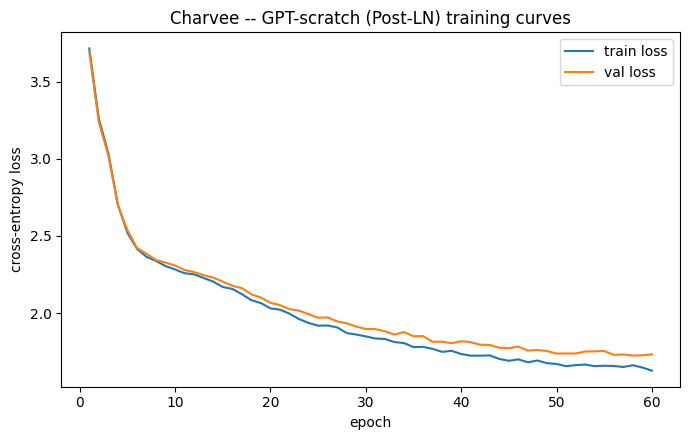

In [6]:
plt.figure(figsize=(7, 4.5))
plt.plot(history["epoch"], history["train_loss"], label="train loss")
plt.plot(history["epoch"], history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("Charvee -- GPT-scratch (Post-LN) training curves")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "loss_curve.png"), dpi=130)
plt.show()

### 1.3.5 Text generation

In [7]:
def generate_text(prompt, max_new_tokens=300, temperature=0.8, greedy=False):
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    out = model.generate(idx, max_new_tokens=max_new_tokens, temperature=temperature, greedy=greedy)
    return decode(out[0].tolist())


t0 = time.time()
samples = []
prompts = ["Once upon a time", "The little dog", "One day, a girl"]
for p in prompts:
    samples.append({"prompt": p, "temperature_0.8": generate_text(p, temperature=0.8)})
    samples.append({"prompt": p, "greedy": generate_text(p, greedy=True)})
gen_time = time.time() - t0
gen_chars = sum(len(s.get("temperature_0.8", s.get("greedy", ""))) for s in samples)
gen_tokens_per_sec = gen_chars / gen_time

with open(os.path.join(OUT_DIR, "generated_samples.json"), "w") as f:
    json.dump(samples, f, indent=2)

for s in samples:
    print("-" * 60)
    print(s)

------------------------------------------------------------
{'prompt': 'Once upon a time', 'temperature_0.8': 'Once upon a timered then the fefulrt. Emoovere sacled ran hould a befaed ways the git plired hand upp eaying stree thee brmet hear.\n\nSuddd ban was tadd, the rrives to a fa ban to moooing hint bep. Sheas was said a the impled cat mom hombens tho dn saived Fit pumped it it her awerong. He nopp, the danked theat ver a'}
------------------------------------------------------------
{'prompt': 'Once upon a time', 'greedy': 'Once upon a time the gore the was started to the was an the so the sared staid the she ward and the was so aid the was the che s ait her was and and she so ane sthe the ploonged the was he and a a bet in the want to the gorket her was ashe sthe was to her wit her was so the sareed and the souch her and the was was '}
------------------------------------------------------------
{'prompt': 'The little dog', 'temperature_0.8': 'The little doge. He roon a and Muin

### Generation-diversity metrics (distinct-n, repeated 4-gram rate)

In [8]:
def ngrams(seq, n):
    return [tuple(seq[i:i + n]) for i in range(len(seq) - n + 1)]


all_gen_text = "".join(s.get("temperature_0.8", s.get("greedy", "")) for s in samples)
distinct = {}
for n in [1, 2, 3]:
    grams = ngrams(all_gen_text, n)
    distinct[f"distinct_{n}"] = len(set(grams)) / max(1, len(grams))

grams4 = ngrams(all_gen_text, 4)
repeated_4gram_rate = 1 - (len(set(grams4)) / max(1, len(grams4)))

### Final metrics report

In [9]:
final_train_loss = history["train_loss"][-1]
final_val_loss = history["val_loss"][-1]
perplexity = math.exp(final_val_loss)
bpc = final_val_loss / math.log(2)
gen_gap = final_val_loss - final_train_loss

metrics_row = {
    "member": "Charvee",
    "architecture": "Post-LN Transformer, untied head, ReLU FFN",
    "n_layer": N_LAYER, "n_head": N_HEAD, "n_embd": N_EMBD, "block_size": BLOCK_SIZE,
    "dropout": DROPOUT, "epochs": N_EPOCHS, "batch_size": BATCH_SIZE, "peak_lr": PEAK_LR,
    "train_loss": final_train_loss,
    "val_loss": final_val_loss,
    "perplexity": perplexity,
    "bits_per_char": bpc,
    "generalization_gap": gen_gap,
    "top1_next_char_acc": history["val_acc"][-1],
    "distinct_1": distinct["distinct_1"],
    "distinct_2": distinct["distinct_2"],
    "distinct_3": distinct["distinct_3"],
    "repeated_4gram_rate": repeated_4gram_rate,
    "grad_norm_mean": sum(grad_norms) / len(grad_norms),
    "grad_norm_max": max(grad_norms),
    "nan_count": nan_count,
    "param_count": n_params,
    "train_tokens_per_sec": train_tokens_per_sec,
    "gen_tokens_per_sec": gen_tokens_per_sec,
    "peak_memory_MB": peak_mem_mb,
    "total_training_time_sec": train_time_sec,
}

import csv
metrics_csv_path = os.path.join(MEMBER_DIR, "metrics_report.csv")
with open(metrics_csv_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(metrics_row.keys()))
    w.writeheader()
    w.writerow(metrics_row)

with open(os.path.join(OUT_DIR, "history.json"), "w") as f:
    json.dump(history, f, indent=2)

torch.save(model.state_dict(), os.path.join(CKPT_DIR, "gpt_charvee.pt"))
log_f.close()

print("\n=== FINAL METRICS (Charvee) ===")
for k, v in metrics_row.items():
    print(f"{k}: {v}")


=== FINAL METRICS (Charvee) ===
member: Charvee
architecture: Post-LN Transformer, untied head, ReLU FFN
n_layer: 6
n_head: 4
n_embd: 96
block_size: 96
dropout: 0.15
epochs: 60
batch_size: 48
peak_lr: 0.0005
train_loss: 1.627331018447876
val_loss: 1.732969045639038
perplexity: 5.657426153776482
bits_per_char: 2.50014584815752
generalization_gap: 0.10563802719116211
top1_next_char_acc: 0.4777560763888889
distinct_1: 0.020634920634920634
distinct_2: 0.13340391741662255
distinct_3: 0.3305084745762712
repeated_4gram_rate: 0.5135135135135135
grad_norm_mean: 0.9822005972765708
grad_norm_max: 14.087303271507185
nan_count: 0
param_count: 698205
train_tokens_per_sec: 105789.2008294424
gen_tokens_per_sec: 139.5025462112928
peak_memory_MB: 273.14432
total_training_time_sec: 54.883484840393066
